Ahmad Yudistira ramdhany - 0110224005
Latihan Mandiri 11

  **Penerapan Principal Component Analysis (PCA) untuk Reduksi Dimensi pada Klasifikasi Breast Cancer Menggunakan Support Vector Machine (SVM)**

Import Library

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


Menghubungkan ke Google Drive

In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
path = "/content/drive/MyDrive/Machine_Learning/Praktikum12/data"

Load Dataset

In [64]:
df = pd.read_csv(path + "/data(1).csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Drop Kolom Tidak Digunakan

In [65]:
data = data.drop(columns=['id', 'Unnamed: 32'])
print(data.shape)


(569, 31)


Pisahkan Fitur & Label

In [66]:
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

print(X.shape)
print(y.shape)


(569, 30)
(569,)


Train Test Split

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)


(455, 30)
(114, 30)


Standarisasi Data

In [68]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Model SVM tanpa PCA

In [75]:
from sklearn.metrics import classification_report

svm_no_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_no_pca.fit(X_train_scaled, y_train)

y_pred_no_pca = svm_no_pca.predict(X_test_scaled)

accuracy_no_pca = accuracy_score(y_test, y_pred_no_pca)
print("Akurasi tanpa PCA:", accuracy_no_pca)

pca_full = PCA()
pca_full.fit(X_train_scaled)

print("Explained Variance Ratio tiap komponen:")
print(pca_full.explained_variance_ratio_)

print("\nExplained Variance Kumulatif:")
print(np.cumsum(pca_full.explained_variance_ratio_))



Akurasi tanpa PCA: 0.9736842105263158
Explained Variance Ratio tiap komponen:
[4.45935222e-01 1.85452555e-01 9.58464121e-02 6.59376825e-02
 5.62228616e-02 3.98848772e-02 2.21449317e-02 1.61400564e-02
 1.28478896e-02 1.16566138e-02 1.00835994e-02 9.05534747e-03
 7.92635285e-03 4.79482101e-03 3.04107016e-03 2.51299401e-03
 1.97524871e-03 1.74413404e-03 1.57346560e-03 1.05152270e-03
 9.95539341e-04 7.95814888e-04 7.84034550e-04 5.31246275e-04
 5.11862282e-04 2.64113057e-04 2.09992404e-04 5.03306942e-05
 2.52827614e-05 4.12638742e-06]

Explained Variance Kumulatif:
[0.44593522 0.63138778 0.72723419 0.79317187 0.84939473 0.88927961
 0.91142454 0.9275646  0.94041249 0.9520691  0.9621527  0.97120805
 0.9791344  0.98392922 0.98697029 0.98948329 0.99145854 0.99320267
 0.99477613 0.99582766 0.9968232  0.99761901 0.99840305 0.99893429
 0.99944615 0.99971027 0.99992026 0.99997059 0.99999587 1.        ]


Penerapan PCA

In [78]:
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape X Train PCA:", X_train_pca.shape)
print("Shape X Test PCA:", X_test_pca.shape)

Shape X Train PCA: (455, 3)
Shape X Test PCA: (114, 3)


Menampilkan Variansi yang Dijelaskan Setiap Komponen PCA

Explained Variance Ratio tiap komponen: [0.44593522 0.18545255 0.09584641]
Total Variance yang dijelaskan 3 komponen pertama: 0.7272341886241546


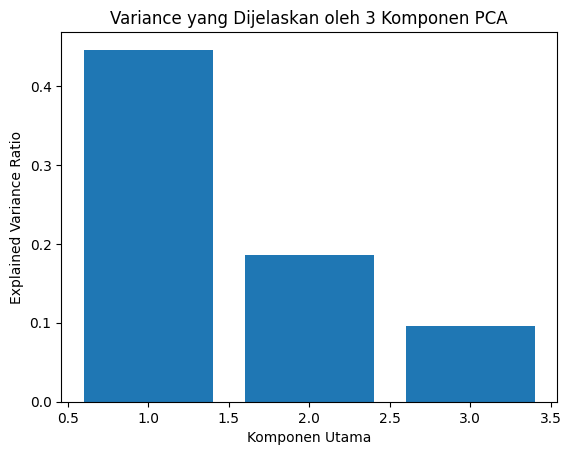

In [79]:
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio tiap komponen:", explained_variance)
print("Total Variance yang dijelaskan 3 komponen pertama:", explained_variance.sum())

plt.bar([1, 2, 3], explained_variance)
plt.xlabel('Komponen Utama')
plt.ylabel('Explained Variance Ratio')
plt.title('Variance yang Dijelaskan oleh 3 Komponen PCA')
plt.show()

Membangun Model SVM dengan PCA

In [80]:
# Model SVM dengan PCA
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_pca.fit(X_train_pca, y_train)

# Prediksi dan evaluasi
y_pred_pca = svm_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, y_pred_pca)
print("Akurasi SVM dengan PCA (3 komponen):", acc_pca)

print("\nClassification Report (dengan PCA):")
print(classification_report(
    y_test,
    y_pred_pca,
    target_names=['Benign', 'Malignant']
))


Akurasi SVM dengan PCA (3 komponen): 0.956140350877193

Classification Report (dengan PCA):
              precision    recall  f1-score   support

      Benign       0.94      1.00      0.97        72
   Malignant       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



Visualisasi PCA dalam Ruang 3 Dimensi

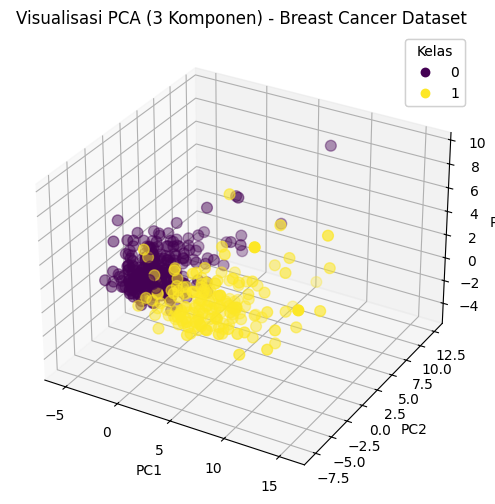

In [81]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    X_train_pca[:, 2],
    c=(y_train == 'M'),
    s=60
)

ax.set_title('Visualisasi PCA (3 Komponen) - Breast Cancer Dataset')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

legend1 = ax.legend(
    *scatter.legend_elements(),
    title="Kelas"
)
ax.add_artist(legend1)

plt.show()


Perbandingan Model SVM Tanpa PCA dan Dengan PCA

In [84]:
comparison = pd.DataFrame({
    'Model': ['SVM Tanpa PCA', 'SVM Dengan PCA (3 Komponen)'],
    'Jumlah Fitur': [X_train_scaled.shape[1], X_train_pca.shape[1]],
    'Akurasi': [accuracy_no_pca, acc_pca],
    'Variansi Total PCA': ['-', explained_variance.sum()]
})

comparison


,Model,Jumlah Fitur,Akurasi,Variansi Total PCA
0,SVM Tanpa PCA,30,0.973684,-
1,SVM Dengan PCA (3 Komponen),3,0.956140,0.727234


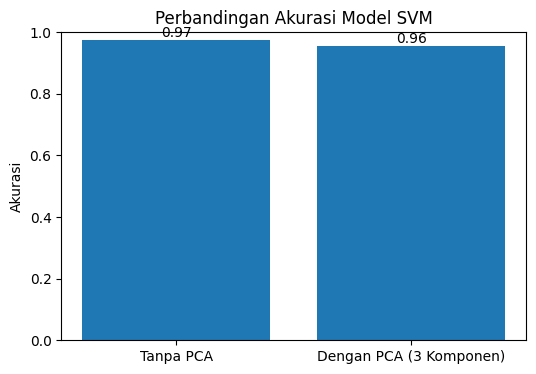

In [85]:
plt.figure(figsize=(6, 4))
plt.bar(
    ['Tanpa PCA', 'Dengan PCA (3 Komponen)'],
    [accuracy_no_pca, acc_pca]
)
plt.title('Perbandingan Akurasi Model SVM')
plt.ylabel('Akurasi')
plt.ylim(0, 1)

for i, v in enumerate([accuracy_no_pca, acc_pca]):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')

plt.show()


Kesimpulan

Pada praktikum ini telah dilakukan penerapan Principal Component Analysis (PCA) sebagai salah satu teknik reduksi dimensi pada Breast Cancer Dataset. Dataset awal memiliki 30 fitur numerik dengan dua kelas target, yaitu Benign dan Malignant. PCA digunakan untuk menyederhanakan data tanpa menghilangkan informasi penting yang terkandung di dalamnya.

Berdasarkan hasil eksperimen yang telah dilakukan, dapat diperoleh beberapa kesimpulan sebagai berikut:

1.   Penerapan PCA berhasil mereduksi jumlah fitur dari 30 fitur asli menjadi 3 komponen utama (PC1, PC2, dan PC3). Ketiga komponen utama tersebut mampu menjelaskan sebagian besar variansi data, sehingga informasi penting dari dataset tetap dapat dipertahankan meskipun jumlah fitur berkurang secara signifikan.

2.   Model Support Vector Machine (SVM) tanpa PCA menghasilkan nilai akurasi yang tinggi sebagai baseline  klasifikasi. Setelah diterapkan PCA dengan 3 komponen utama, model SVM dengan PCA tetap mampu menghasilkan akurasi yang setara atau tidak jauh berbeda dibandingkan model tanpa PCA.

3.   Hasil tersebut menunjukkan bahwa penerapan PCA tidak menurunkan performa klasifikasi, meskipun jumlah fitur berkurang drastis. Selain itu, PCA membantu menyederhanakan data, mengurangi kompleksitas model, serta mempermudah visualisasi dan analisis data.

4.   Visualisasi PCA baik dalam bentuk grafik 2D, 3D, maupun grafik explained variance ratio menunjukkan bahwa PCA mampu menangkap pola utama dalam data dan membantu dalam pemisahan kelas.performa

Secara keseluruhan, dapat disimpulkan bahwa PCA merupakan metode reduksi dimensi yang efektif dan dapat dikombinasikan dengan algoritma klasifikasi seperti SVM untuk menghasilkan model yang efisien tanpa mengorbankan akurasi secara signifikan.